## Análisis exploratorio - 3.1 Análisis univariable

### By:
Maria Camila Aristizábal Aguirre

### Date:
2026-08-17

### Description:
Análisis univariable: distribución de la variable objetivo y de cada variable numérica.

## 📚 Import  libraries

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.float_format", "{:.2f}".format)

DATA_DIR = Path("../../data")

## 💾 Load data

In [4]:
df = pd.read_parquet(DATA_DIR / "02_intermediate" / "diabetes_type_fixed.parquet")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 994 entries, 0 to 993
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               986 non-null    Int8   
 1   Glucose                   982 non-null    float64
 2   BloodPressure             942 non-null    float64
 3   SkinThickness             689 non-null    float64
 4   Insulin                   501 non-null    float64
 5   BMI                       978 non-null    float64
 6   DiabetesPedigreeFunction  989 non-null    float64
 7   Age                       991 non-null    Int8   
 8   Outcome                   975 non-null    boolean
dtypes: Int8(2), boolean(1), float64(6)
memory usage: 52.5 KB


## Variable objetivo: Outcome

Outcome
False    630
True     345
<NA>      19
Name: count, dtype: Int64

Outcome
False   63.40
True    34.70
<NA>     1.90
Name: proportion, dtype: Float64


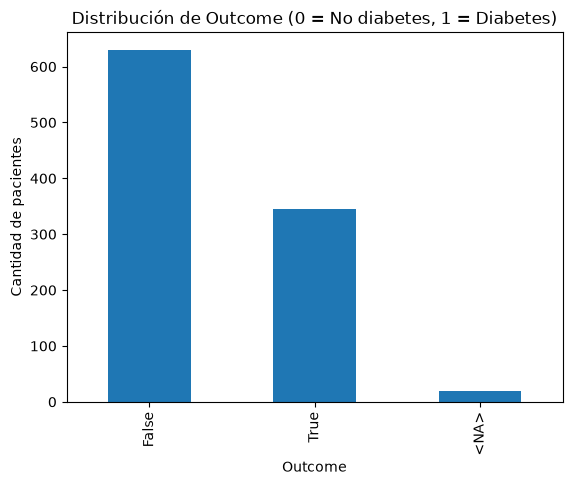

In [ ]:
conteo_outcome = df["Outcome"].value_counts(dropna=False)
pct_outcome = df["Outcome"].value_counts(normalize=True, dropna=False) * 100

print(conteo_outcome)
print()
print(pct_outcome.round(1))

conteo_outcome.plot(kind="bar", title="Distribución de Outcome (0 = No diabetes, 1 = Diabetes)")
plt.xlabel("Outcome")
plt.ylabel("Cantidad de pacientes")
plt.show()

## Variables numéricas: estadísticas descriptivas


In [6]:
COLUMNAS_NUMERICAS = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
]

resumen = df[COLUMNAS_NUMERICAS].describe().T
resumen["nunique"] = df[COLUMNAS_NUMERICAS].nunique()
resumen["skew"] = df[COLUMNAS_NUMERICAS].skew()
resumen["kurtosis"] = df[COLUMNAS_NUMERICAS].kurtosis()
resumen

,count,mean,std,min,25%,50%,75%,max,nunique,skew,kurtosis
Pregnancies,986.00,3.90,3.39,0.00,1.00,3.00,6.00,17.00,17,0.90,0.17
Glucose,982.00,121.67,30.44,44.00,100.00,117.00,141.00,199.00,135,0.50,-0.28
BloodPressure,942.00,72.43,12.52,24.00,64.00,72.00,80.00,122.00,46,0.16,0.95
SkinThickness,689.00,28.96,10.45,7.00,21.00,29.00,36.00,99.00,50,0.60,2.31
Insulin,501.00,155.44,120.50,14.00,76.00,125.00,191.00,846.00,185,2.28,7.24
BMI,978.00,32.41,6.92,18.20,27.40,32.15,36.60,67.10,247,0.54,0.63
DiabetesPedigreeFunction,989.00,0.47,0.33,0.08,0.25,0.37,0.62,2.42,517,1.86,5.10
Age,991.00,33.31,11.68,21.00,24.00,29.00,41.00,81.00,52,1.10,0.52


## Reglas de validación de datos

A partir del análisis univariable, se definen las siguientes reglas de validación
para usarse en etapas posteriores del proyecto.

In [7]:
COLUMNAS_CERO_INVALIDO = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

reglas_validacion = pd.DataFrame(
    {
        "columna": COLUMNAS_NUMERICAS,
        "minimo_observado": df[COLUMNAS_NUMERICAS].min().values,
        "maximo_observado": df[COLUMNAS_NUMERICAS].max().values,
    }
)
reglas_validacion["regla_sugerida"] = reglas_validacion.apply(
    lambda fila: (
        f"> 0 y <= {fila['maximo_observado']:.2f} (0 no es valido, se trata como dato faltante)"
        if fila["columna"] in COLUMNAS_CERO_INVALIDO
        else f">= {fila['minimo_observado']:.2f} y <= {fila['maximo_observado']:.2f}"
    ),
    axis=1,
)
reglas_validacion

,columna,minimo_observado,maximo_observado,regla_sugerida
0,Pregnancies,0.00,17.00,>= 0.00 y <= 17.00
1,Glucose,44.00,199.00,"> 0 y <= 199.00 (0 no es valido, se trata como..."
2,BloodPressure,24.00,122.00,"> 0 y <= 122.00 (0 no es valido, se trata como..."
3,SkinThickness,7.00,99.00,"> 0 y <= 99.00 (0 no es valido, se trata como ..."
4,Insulin,14.00,846.00,"> 0 y <= 846.00 (0 no es valido, se trata como..."
5,BMI,18.20,67.10,"> 0 y <= 67.10 (0 no es valido, se trata como ..."
6,DiabetesPedigreeFunction,0.08,2.42,>= 0.08 y <= 2.42
7,Age,21.00,81.00,>= 21.00 y <= 81.00


## Distribuciones: histogramas


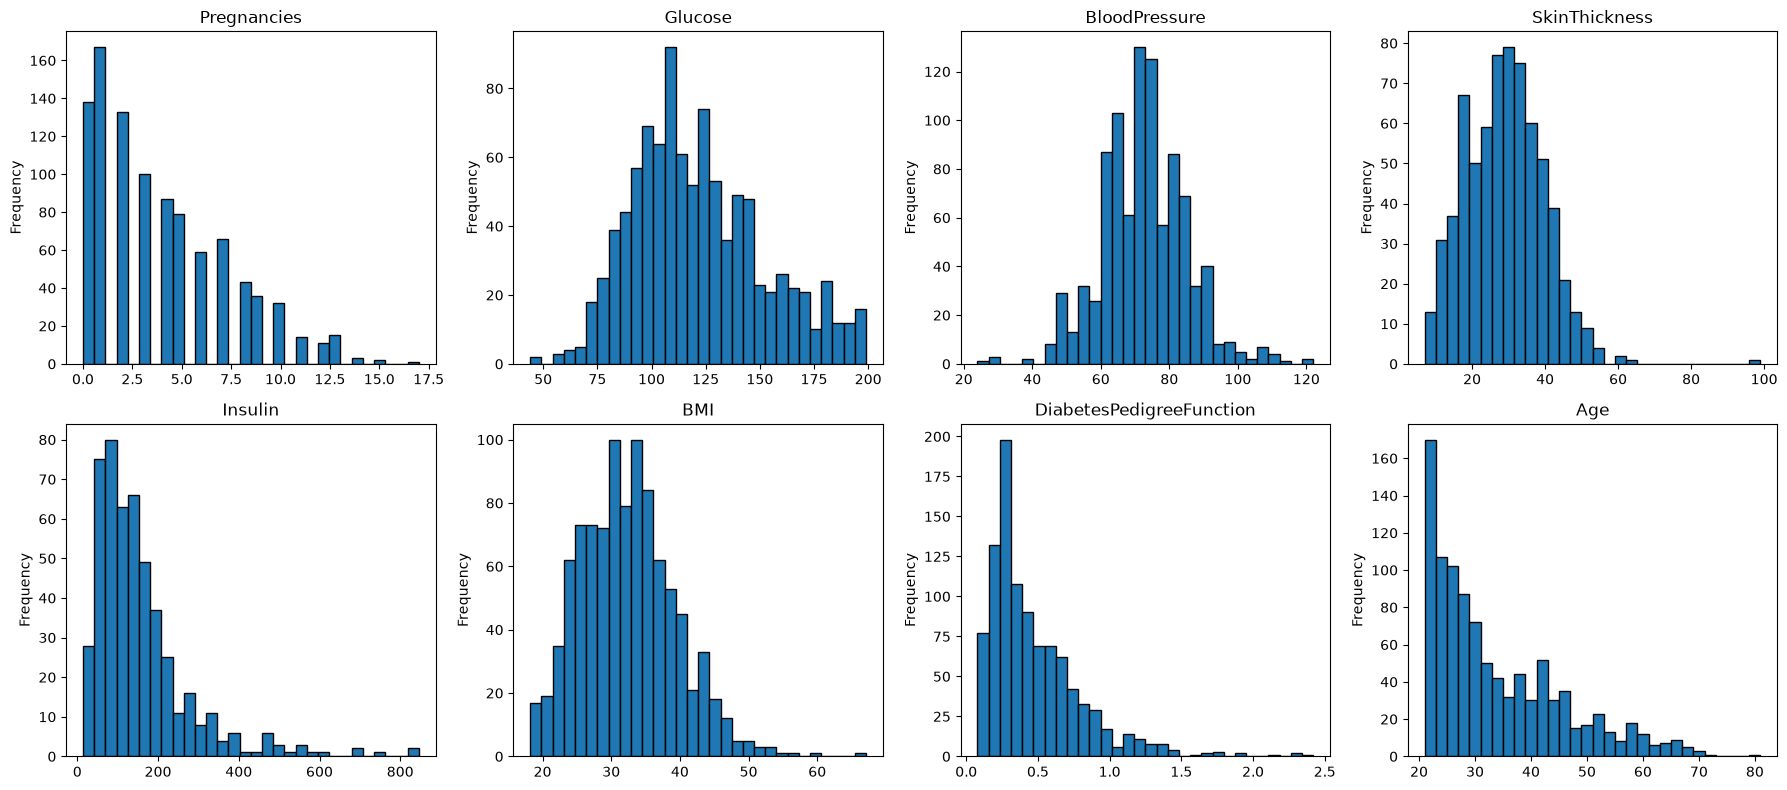

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for col, ax in zip(COLUMNAS_NUMERICAS, axes.flatten(), strict=True):
    df[col].plot(kind="hist", bins=30, ax=ax, edgecolor="black")
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Distribuciones: boxplots (detección de outliers)

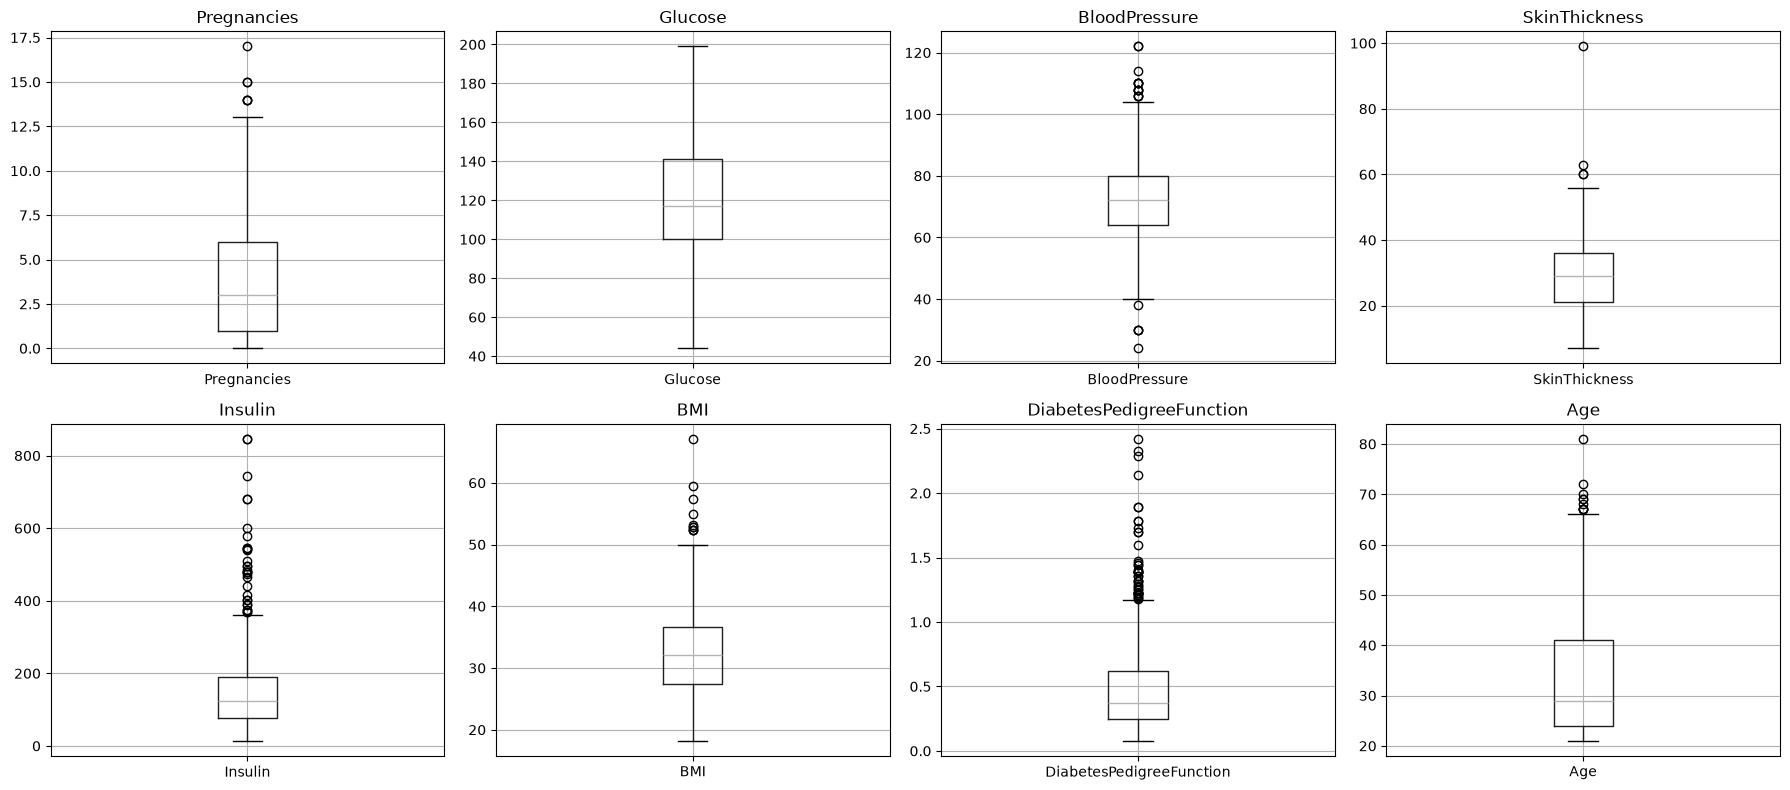

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for col, ax in zip(COLUMNAS_NUMERICAS, axes.flatten(), strict=True):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Hallazgos

### Variable objetivo (Outcome)
De los 994 registros, 630 (63.4%) no tienen diabetes, 345 (34.7%) sí, y 19 (1.9%) no tienen la etiqueta registrada. Es un desbalance moderado, no extremo — un modelo que prediga siempre "no diabetes" alcanzaría ~63-65% de accuracy sin ser útil, lo que confirma que accuracy solo no es una métrica adecuada.

### Variables numéricas: forma de la distribución

Según el coeficiente de asimetría (`skew`), las variables se agrupan en tres niveles:

- **Casi simétrica**: `BloodPressure` (skew 0.16) es la más cercana a una distribución normal de las 8 variables.
- **Asimetría moderada a la derecha**: `Glucose` (0.50), `BMI` (0.54), `SkinThickness` (0.60) — un solo pico con una cola derecha suave.
- **Asimetría fuerte a la derecha**: `Pregnancies` (0.90) y `Age` (1.10) — concentradas en valores bajos (pocas gestaciones, pacientes jóvenes), con una cola larga hacia valores altos.
- **Asimetría muy fuerte con outliers marcados**: `DiabetesPedigreeFunction` (1.86) e `Insulin` (2.28, la más sesgada de todas) — se ve claramente en los boxplots, con muchos puntos atípicos por encima del bigote superior.

### Outliers (boxplots)

`Insulin` tiene los outliers más extremos y numerosos (hasta 846, frente a una mediana de 125), consistente con su alto sesgo. `DiabetesPedigreeFunction` también muestra varios puntos atípicos por encima de ~1.2. `SkinThickness` tiene un único valor extremo cerca de 99, claramente separado del resto de la distribución (75% de los datos está por debajo de 36) — candidato a revisar como posible error de captura en la etapa de Feature Engineering. `Age`, `BMI`, `BloodPressure` y `Glucose` tienen outliers superiores más moderados.

### Preparación de datos identificada para etapas posteriores

- `Insulin` (49.6% de nulos) y `SkinThickness` (30.7% de nulos) tienen la mayor proporción de valores faltantes de las 8 variables — la estrategia de imputación deberá elegirse con cuidado, ya que un método simple (media/mediana) podría distorsionar casi un tercio o la mitad de los datos.
- `Insulin` y `DiabetesPedigreeFunction`, por su fuerte asimetría, son candidatas a una transformación (ej. logarítmica) antes de modelar.
- Los rangos de las variables son muy distintos entre sí (`Insulin` 14–846 vs. `DiabetesPedigreeFunction` 0.08–2.42), por lo que será necesario escalar los atributos antes de entrenar modelos sensibles a la escala.
